1. This notebook sets up the necessary libraries and environment for a MIMO detection. At present, we use CDL channel with 16qam modulation. The LMMSE equalizer is used as a tentative baseline for comparison.

2. Simple Model comprises 5 Detnet layers (Tentative count of parameters ~4900)

------ y and h are generated on-the-go based on the count of epochs

------ rx = 8; tx = 4; h = (8,4)  --> 1 sample

------ batch = group of samples = 512

------ step = 1 iteration of training loop done on one batch

------ steps = 200 -->  200 * 512 = 102,400 samples, which is appx 20 times 4900

# Libraries

In [ ]:
# %pip install sionna -U -q

In [1]:
## To configure CPU / GPU usage, suppress Tensorflow warnings, Install Sionna and set a reproducible seed

import os
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

# Set random seed for reproducability
sionna.phy.config.seed = 42

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 28.2 MB/s eta 0:00:00


In [3]:
import os
import sys
import tensorflow as tf

import numpy as np  ## Computations
from sionna.phy import Block  ## Base class for physical layer components
from sionna.phy.utils import compute_ser  ## Utility to compute Symbol Error Rate (SER)
# from sionna.phy.channel import FlatFadingChannel,  KroneckerModel  ## Rayleigh Flat-Fading Channel Model
from sionna.phy.channel.utils import exp_corr_mat  ## Exponential correlation matrics (based on antenna distance)
from sionna.phy.mimo import lmmse_equalizer  ## LLMSE Equaliser (Could be a baseline for Projective Gradient Descent Method Comparison)
from sionna.phy.mapping import SymbolDemapper, Mapper, QAMSource  ## QAM Symbol Mapping and Demapping Utilities

## Visualisation
%matplotlib inline
import matplotlib.pyplot as plt  ## For Static Plotting
import plotly.graph_objects as go  ## For Interactive Plotting
from plotly.subplots import make_subplots  ## Create Subplots in a single figure

from tqdm import tqdm  ## To track runtime progress

In [4]:
import optuna

## Import libraries specifc to CDL Channel

In [5]:
from sionna.phy.mimo import StreamManagement  ## To handle multiple parallel data streams

from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, OFDMModulator, OFDMDemodulator, RZFPrecoder, RemoveNulledSubcarriers
# - ResourceGrid: defines the OFDM time–frequency grid (slots, subcarriers, pilots, etc.)
# - ResourceGridMapper: maps encoded symbols onto the grid (data + pilot placement)
# - LSChannelEstimator: least-squares channel estimation from pilot symbols
# - OFDMModulator: converts mapped symbols to time-domain OFDM waveforms (IFFT + CP)
# - OFDMDemodulator: inverse of above (removes CP + FFT back to frequency domain)
# - RZFPrecoder: regularized zero-forcing precoder for downlink multi-user MIMO
# - RemoveNulledSubcarriers: removes unused subcarriers (e.g., guard bands, DC)

from sionna.phy.channel.tr38901 import AntennaArray, CDL
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel, cir_to_time_channel, time_lag_discrete_time_channel, ApplyOFDMChannel, ApplyTimeChannel, OFDMChannel, TimeChannel
# - subcarrier_frequencies: computes OFDM subcarrier frequencies
# - cir_to_ofdm_channel: converts channel impulse response (CIR) → OFDM domain channel
# - cir_to_time_channel: converts CIR → time-domain discrete channel taps
# - time_lag_discrete_time_channel: generates time-lagged discrete channel representation
# - ApplyOFDMChannel: applies channel directly in frequency domain
# - ApplyTimeChannel: applies channel in time domain
# - OFDMChannel: convenience wrapper for OFDM channel simulation
# - TimeChannel: convenience wrapper for time-domain channel simulation

from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder  # If not already present
from sionna.phy.utils import ebnodb2no, sim_ber, compute_ber

In [6]:
# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Just checking a sample CDL dataset

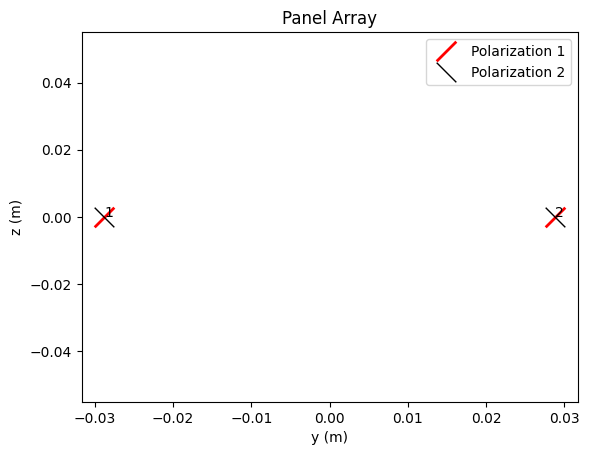

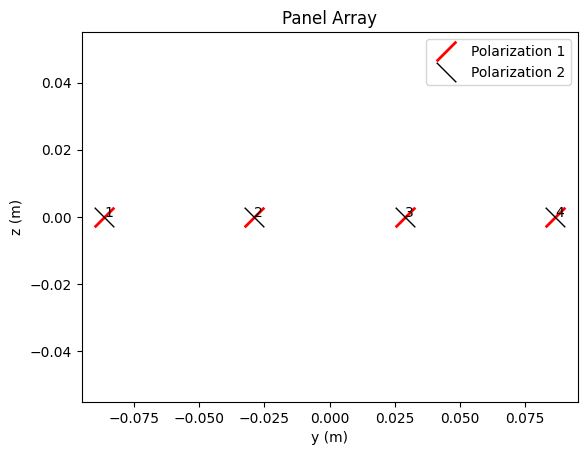

In [7]:
# Fixed parameters based on requirements
num_tx_ant = 4  # Example transmitter antennas; adjust as needed
num_rx_ant = 8  # 2x transmitter (or set to 16 for 4x)
sample_size = 500  # 500 channel realisations

num_bits_per_symbol = 4  # Keep for 16-QAM

carrier_frequency = 2.6e9  # Hz, as in tutorial
delay_spread = 300e-9  # Seconds, as in tutorial; adjust if needed
direction = "uplink"  # Or "downlink"
cdl_model = "B"  # Example from tutorial; choose A-E based on needs
speed = 10  # m/s, from tutorial

no = 0.25 ## scaling awgn during transmission

ut_array = AntennaArray(num_rows=1,
                        num_cols=int(num_tx_ant / 2),  # For dual polarization (cross, 2 parts)
                        polarization="dual",
                        polarization_type="cross",  # Cross-polarization (1,2, or 4 parts via num_cols)
                        antenna_pattern="38.901",  # Default
                        carrier_frequency=carrier_frequency)
bs_array = AntennaArray(num_rows=1,
                        num_cols=int(num_rx_ant / 2),
                        polarization="dual",
                        polarization_type="cross",
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)


ut_array.show()
bs_array.show()

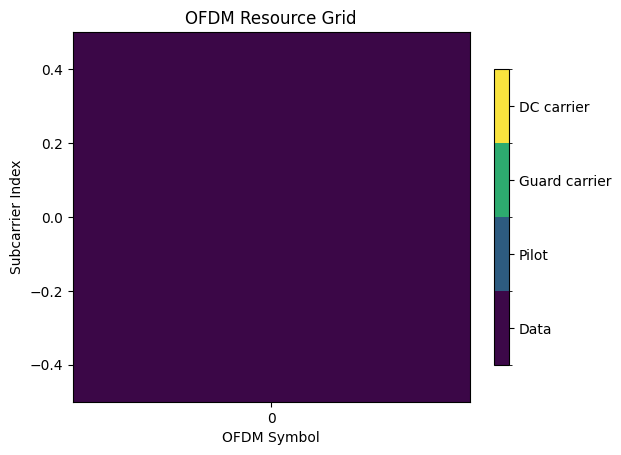

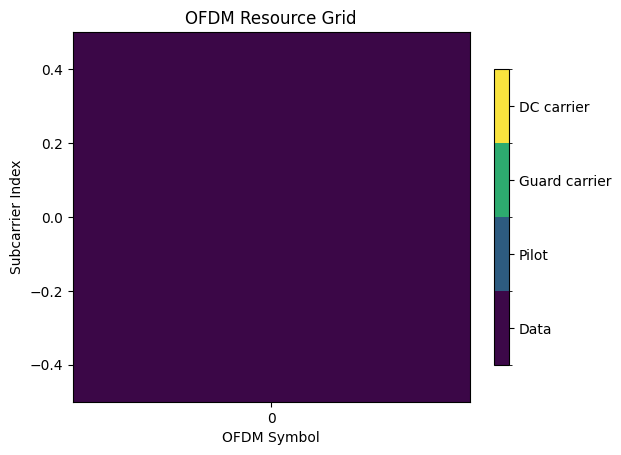

In [8]:
rg = ResourceGrid(  # Correct: Defines OFDM grid; minimal here for simplicity.
    num_ofdm_symbols=1,           # Number of OFDM symbols in the time domain (1 here)  # Single symbol: No time-varying.
    fft_size=1,                  # FFT size → number of subcarriers in frequency domain  # =1: Key simplification; flat-fading approx (no selectivity).
    subcarrier_spacing=15e3,       # Subcarrier spacing in Hz (15 kHz typical for LTE/5G)  # Standard; with fft_size=1, bandwidth=15kHz (narrowband).
    num_tx=1,                      # Number of transmit antennas (or antenna ports) used in grid  # =1: Treats UE as single "tx" with streams.
    num_streams_per_tx=num_tx_ant # Number of spatial streams per transmit antenna  # =4: MIMO layers = ants (full rank assumption).
)
rg.show()  # Good debug: Plots grid (pilots, guards—minimal here).

In [9]:
cdl = CDL(cdl_model, delay_spread, carrier_frequency, ut_array, bs_array, direction, min_speed=speed)  # Instantiates CDL with params; loads 3GPP tables for "B".

a, tau = cdl(batch_size=sample_size, num_time_steps=1, sampling_frequency=1/rg.ofdm_symbol_duration)  # Generates CIR; a (gains), tau (delays). sampling_freq from rg (high for small symbol duration)
frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)  # [0] Hz since fft_size=1
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)  # Transforms to freq-domain; normalize for unit power. h ~ [500,1,8,1,4,1,1].

# Reshape h to desired dimension: [batch_size, 1 (num_ues), num_tx_ant, 1 (num_rx_base), num_rx_ant, 1 (time), 500 (freq)]
#h = tf.transpose(h_freq, [0, 3, 4, 1, 2, 5, 6])  # Adjust indices: original [bs, rx=1, rx_ant, tx=1, tx_ant, time=1, freq=500]

h =h_freq
print("Shape of h:", h.shape)  # Verify

# Generate QAM symbols
qam_source = QAMSource(num_bits_per_symbol)
x_symbols = qam_source([sample_size, num_tx_ant])  # shape: [batch, tx_ant] aka 500,4


# For fft_size=1, no need for complex tiling; reshape for ResourceGridMapper
# ResourceGrid expects [batch, num_tx=1, num_streams_per_tx=4, num_ofdm_symbols=1, fft_size=1]
x_mapped = tf.reshape(x_symbols, [sample_size, 1, num_tx_ant, 1, 1])  # [500, 1, 4, 1, 1]
print("Shape of x_mapped:", x_mapped.shape)
print("Sum of x_mapped:", tf.reduce_sum(tf.abs(x_mapped)).numpy())


# Simulate y using CDL channel
channel = ApplyOFDMChannel(add_awgn=True)
y = channel(x_mapped, h, no)  # [500, 1, 8, 1, 1]
print("Shape of y:", y.shape)
print("Sum of y:", tf.reduce_sum(tf.abs(y)).numpy())

# Squeeze for PGD compatibility (assuming flat-fading PGD)
h_squeezed = tf.squeeze(h, axis=[1, 3, 5, 6])  # [500, 8, 4]
y_squeezed = tf.squeeze(y, axis=[1, 3, 4])  # [500, 8]
x_squeezed = tf.squeeze(x_mapped, axis=[1, 3, 4])  # [500, 4]
print("Squeezed shapes for PGD: h", h_squeezed.shape, "y", y_squeezed.shape, "x", x_squeezed.shape)

Shape of h: (500, 1, 8, 1, 4, 1, 1)
Shape of x_mapped: (500, 1, 4, 1, 1)
Sum of x_mapped: 1893.7933
Shape of y: (500, 1, 8, 1, 1)
Sum of y: 7202.1626
Squeezed shapes for PGD: h (500, 8, 4) y (500, 8) x (500, 4)


## LMMSE Equaliser on CDL

Effective Noise Variance (LMMSE): 0.12877844
Theoretical Estimated Noise Variance (LMMSE): 0.12824635
Symbol Error Rate (LMMSE): 0.2575


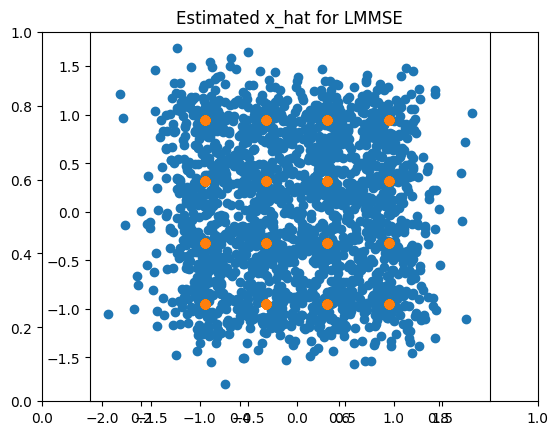

In [10]:
y = y_squeezed
h = h_squeezed
x = x_squeezed

symbol_demapper = SymbolDemapper("qam", num_bits_per_symbol, hard_out=True)  # QAM symbol demapper (hard decision) to map received signals back to symbol indices
x_ind = symbol_demapper(x, no)  # Get true transmitted symbol indices from original QAM symbols
s = tf.cast(no * tf.eye(num_rx_ant, num_rx_ant), y.dtype)  # Regularization matrix for LMMSE: s = σ_n² * I (noise variance times identity)

x_hat_lmmse, no_eff = lmmse_equalizer(y, h, s)   # Apply LMMSE equalizer to estimate transmitted symbols and get effective noise variance
x_ind_lmmse = symbol_demapper(x_hat_lmmse, no)  # Demap LMMSE-estimated symbols to indices

ser_lmmse = compute_ser(x_ind, x_ind_lmmse)  # Compute Symbol Error Rate (SER) between true and LMMSE-estimated symbols

noise_var_eff = np.var(x - x_hat_lmmse)  # Compute effective noise variance from LMMSE estimates
noise_var_est = np.mean(no_eff)           # Theoretical estimated noise variance

print("Effective Noise Variance (LMMSE):", noise_var_eff)  ## Just confirming the correctness of the LMMSE estimate
print("Theoretical Estimated Noise Variance (LMMSE):", noise_var_est)
print("Symbol Error Rate (LMMSE):", ser_lmmse.numpy())  # SER achieved by LMMSE baseline


## Plotting Transmitted and Received Constellation
plt.title("Estimated x_hat for LMMSE")
plt.axes().set_aspect(1.0)
plt.scatter(np.real(x_hat_lmmse), np.imag(x_hat_lmmse));
plt.scatter(np.real(x), np.imag(x));

# Mapper Function (Auxiliary, Not Used in ML)

In [11]:
mapper = Mapper("qam", num_bits_per_symbol) ## Initialize a Mapper for 16-QAM with specified bits per symbol
constellation = mapper.constellation.points.numpy()  ## Extract the constellation points as a NumPy array
print("16-QAM Constellation Points:", constellation)

## Could not find the utility in Sionna that maps indices of QAM constellation to the corresponding complex numbers. Hence done manally. Verified the correctness
constellation_dict = {i: constellation[i] for i in range(16)}  # Create a dictionary mapping indices to complex values

@tf.function
def map_indices_to_complex(indices):
    """Maps integer indices to complex constellation points using tf.gather."""
    indices = tf.clip_by_value(indices, 0, 15) # Ensure indices are within valid range [0, 15]
    constellation_tensor = tf.convert_to_tensor(list(constellation_dict.values()), dtype=tf.complex64) # Convert constellation dictionary to a tensor
    mapped_values = tf.gather(constellation_tensor, indices) # Use tf.gather to map indices to constellation points
    return tf.reshape(mapped_values, tf.shape(indices)) # Reshape to maintain original shape

## Just checking the output of indices and corresponding constellation
# print(x_ind_lmmse)

# dummy_sample = map_indices_to_complex(x_ind_lmmse)
# print("\n\n",dummy_sample)


16-QAM Constellation Points: [ 0.31622776+0.31622776j  0.31622776+0.94868326j  0.94868326+0.31622776j
  0.94868326+0.94868326j  0.31622776-0.31622776j  0.31622776-0.94868326j
  0.94868326-0.31622776j  0.94868326-0.94868326j -0.31622776+0.31622776j
 -0.31622776+0.94868326j -0.94868326+0.31622776j -0.94868326+0.94868326j
 -0.31622776-0.31622776j -0.31622776-0.94868326j -0.94868326-0.31622776j
 -0.94868326-0.94868326j]


# DetNet Model

### Tensorflow libraries

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import time

### Class for a single DetNet Layer

In [13]:
# This class implements the logic of one iteration from the paper (Eq. 10)
class DetNetLayer(layers.Layer):  ## A single customised layer is defined
    def __init__(self, num_tx_ant, hidden_dim, **kwargs):  ## Constructor for the layer
        super(DetNetLayer, self).__init__(**kwargs)   ## Initialise
        self.num_tx_ant = num_tx_ant

        # W1k according to the paper: Lifts concatenated input to a higher dimension. Concatenated input vector forced to be multiplied with W to result in condensed output capturing important info
        self.w1 = layers.Dense(hidden_dim, name="W1")

        # W2k: Projects back to produce the next symbol estimate x(k+1)
        self.w2 = layers.Dense(2 * num_tx_ant, name="W2") # Output is 2*K for real/imag parts of x

        # W3k to update the auxiliary hidden state v(k+1)
        self.w3 = layers.Dense(hidden_dim, name="W3")

    def call(self, inputs):

        x_k, v_k, H_adj_y, H_HH = inputs  ## Just unpacking the inputs to separate entities

        H_HH_x = tf.squeeze(tf.matmul(H_HH, tf.expand_dims(x_k, -1)), -1)   ## Hessian term  sample_size, tx  (tx * rx with rx * tx  whole with tx * 1 = tx*1) => batch_size, tx, 1  ; expand x_k from sample_size, tx to sample. tx, 1

        # 2. Prepare inputs for concatenation (as real values)
        x_k_real = tf.concat([tf.math.real(x_k), tf.math.imag(x_k)], axis=1)  ## Along the second dimension AKA COLUMN
        H_adj_y_real = tf.concat([tf.math.real(H_adj_y), tf.math.imag(H_adj_y)], axis=1)

        # Concatenate inputs as specified in the paper
        # The paper uses [H^T*y, x_k, H^T*H*x_k, v_k]. A slight variant inspired by the gradient step: x_k and (H^T*y - H^T*H*x_k) is used
        # We'll stick to the paper's direct concatenation for this example.
        gradient_term = H_adj_y - H_HH_x
        gradient_term_real = tf.concat([tf.math.real(gradient_term), tf.math.imag(gradient_term)], axis=1)

        # Concatenated vector for the first linear layer
        concatenated_input = tf.concat([x_k_real, gradient_term_real, v_k], axis=1)

        # 3. First transformation and ReLU activation (z_k in paper)
        z_k = tf.nn.relu(self.w1(concatenated_input))

        # 4. Generate next symbol estimate (x_{k+1})
        x_update_real = self.w2(z_k)
        # Using Tanh as a generic bounded activation, suitable for constellations  (Is there a possibilty of bounding box?)
        x_update_real = tf.nn.tanh(x_update_real)

        # Adding a residual connection, which is a common practice for deep networks [cite: 208]
        x_k_plus_1_real = x_k_real + x_update_real
        x_k_plus_1 = tf.complex(x_k_plus_1_real[:, :self.num_tx_ant], x_k_plus_1_real[:, self.num_tx_ant:])  ## x+yj

        # 5. Update the hidden state (v_{k+1})
        v_k_plus_1 = self.w3(z_k)

        return x_k_plus_1, v_k_plus_1


    # Add this method
    def get_config(self):
        config = super(DetNetLayer, self).get_config()
        config.update({
            "num_tx_ant": self.num_tx_ant,
            "hidden_dim": self.hidden_dim,
        })
        return config

### Class for the DetNet Model

In [14]:
# --- The Full DetNet Model ---
class DetNet(Model):
    def __init__(self, num_tx_ant, num_layers=10, hidden_dim=8*4, **kwargs):
        super(DetNet, self).__init__(**kwargs)
        self.num_tx_ant = num_tx_ant
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        # Create a list of DetNet layers
        self.detnet_layers = [DetNetLayer(num_tx_ant, hidden_dim) for _ in range(num_layers)]

    def call(self, inputs):
        h, y = inputs
        sample_size = tf.shape(h)[0]

        # Pre-calculate terms that are constant across layers
        H_adj = tf.linalg.adjoint(h)
        H_adj_y = tf.squeeze(tf.matmul(H_adj, tf.expand_dims(y, -1)), -1)
        H_HH = tf.matmul(H_adj, h)

        # Initialize symbol estimates and hidden state
        x_k = tf.zeros([sample_size, self.num_tx_ant], dtype=tf.complex64)  ## With zeros
        v_k = tf.zeros([sample_size, self.hidden_dim], dtype=tf.float32)

        all_x_hats = [] # Store estimates from each layer for the loss function   [Tx,1]

        # The unfolding loop  (10 layers)
        for layer in self.detnet_layers:
            x_k, v_k = layer((x_k, v_k, H_adj_y, H_HH))  ## Output of previous layer fed as input to the current layer
            all_x_hats.append(x_k)

        return all_x_hats  ## List of [] , []

    # Add this method
    def get_config(self):
        config = super(DetNet, self).get_config()
        config.update({
            "num_tx_ant": self.num_tx_ant,
            "num_layers": self.num_layers,
            "hidden_dim": self.hidden_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

### Data Generation Pipeline

In [15]:
def cdl_generator(batch_size, num_tx_ant, num_rx_ant, num_bits_per_symbol, no=0.25, speed=10.0):
    """
    Fixed generator that properly handles CDL channel generation.
    """
    # Initialize Sionna components
    carrier_frequency = 2.6e9
    delay_spread = 300e-9
    direction = "uplink"
    cdl_model = "B"

    ut_array = AntennaArray(
        num_rows=1,
        num_cols=int(num_tx_ant / 2),
        polarization="dual",
        polarization_type="cross",
        antenna_pattern="38.901",
        carrier_frequency=carrier_frequency
    )
    bs_array = AntennaArray(
        num_rows=1,
        num_cols=int(num_rx_ant / 2),
        polarization="dual",
        polarization_type="cross",
        antenna_pattern="38.901",
        carrier_frequency=carrier_frequency
    )
    rg = ResourceGrid(
        num_ofdm_symbols=1,
        fft_size=1,
        subcarrier_spacing=15e3,
        num_tx=1,
        num_streams_per_tx=num_tx_ant
    )

    qam_source = QAMSource(num_bits_per_symbol)
    channel_sim = ApplyOFDMChannel(add_awgn=True)
    frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)

    while True:
        try:
            # Create a new CDL instance for each batch with randomized speed
            random_speed = tf.random.uniform(shape=[], minval=10.0, maxval=30.0)
            cdl = CDL(
                cdl_model,
                delay_spread,
                carrier_frequency,
                ut_array,
                bs_array,
                direction,
                min_speed=float(random_speed.numpy()),  # Convert to Python float
                max_speed=float(random_speed.numpy())   # Set max_speed = min_speed for consistent speed
            )

            # Generate channel
            a, tau = cdl(
                batch_size=batch_size,
                num_time_steps=1,
                sampling_frequency=1/rg.ofdm_symbol_duration
            )

            # Convert to frequency domain
            h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)

            # Generate QAM symbols
            x_symbols = qam_source([batch_size, num_tx_ant])
            x_mapped = tf.reshape(x_symbols, [batch_size, 1, num_tx_ant, 1, 1])

            # Apply channel
            y = channel_sim(x_mapped, h_freq, no)

            # Reshape for output - use tf.reshape instead of squeeze to maintain batch dimension
            h_squeezed = tf.reshape(h_freq, [batch_size, num_rx_ant, num_tx_ant])
            y_squeezed = tf.reshape(y, [batch_size, num_rx_ant])
            x_squeezed = tf.reshape(x_symbols, [batch_size, num_tx_ant])

            # Verify shapes before yielding
            tf.debugging.assert_shapes([
                (h_squeezed, (batch_size, num_rx_ant, num_tx_ant)),
                (y_squeezed, (batch_size, num_rx_ant)),
                (x_squeezed, (batch_size, num_tx_ant))
            ])

            yield (h_squeezed, y_squeezed), x_squeezed

        except tf.errors.InvalidArgumentError as e:
            # If shape error occurs, skip this iteration and try again
            print(f"Warning: Skipping batch due to shape error: {e}")
            continue
        except Exception as e:
            print(f"Error in generator: {e}")
            raise



### Model and Data Parameters

In [16]:
# Model and Data Parameters
NUM_TX_ANT = 4
NUM_RX_ANT = 8
NUM_BITS_PER_SYMBOL = 4 # 16-QAM

# Training Hyperparameters
BATCH_SIZE = 512
TOTAL_TRAINING_STEPS = 200
VALIDATION_STEPS = 40 # How many batches to use for validation
VALIDATION_FREQUENCY = 40  # Validate every 10 steps

## Fixing the noise variance for CDL
FIXED_NO = 0.25


# Define the output signature for the generator
output_signature = (
    (tf.TensorSpec(shape=(None, NUM_RX_ANT, NUM_TX_ANT), dtype=tf.complex64),
     tf.TensorSpec(shape=(None, NUM_RX_ANT), dtype=tf.complex64)),
    tf.TensorSpec(shape=(None, NUM_TX_ANT), dtype=tf.complex64)
)


# For training and validation, set randomize_speed_per_batch=True
train_dataset = tf.data.Dataset.from_generator(
    lambda: cdl_generator(BATCH_SIZE, NUM_TX_ANT, NUM_RX_ANT, NUM_BITS_PER_SYMBOL, no=FIXED_NO),
    output_signature=output_signature
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: cdl_generator(BATCH_SIZE, NUM_TX_ANT, NUM_RX_ANT, NUM_BITS_PER_SYMBOL, no=FIXED_NO),
    output_signature=output_signature
)


# Prefetch for performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

### Loss Function

In [17]:
# --- Loss Function from Detnet Paper ---
def detnet_loss(x_true, x_pred_list, h, y):
    # Calculate the error of the simple Zero-Forcing (ZF) / decorrelator detector
    h_t = tf.transpose(h, perm=[0, 2, 1])  ## sample,rx,tx to sample,tx,rx
    hth_inv = tf.linalg.inv(tf.matmul(h_t, h))   ## sample, tx,tx
    x_zf = tf.squeeze(tf.matmul(tf.matmul(hth_inv, h_t), tf.expand_dims(y, -1)), axis=-1)    ## Sample, tx, tx * sample tx,rx  * sample,rx,1

    # Add a small epsilon to prevent division by zero
    zf_error = tf.reduce_mean(tf.square(tf.abs(x_true - x_zf)), axis=1) + 1e-9      # x - zf_error

    total_loss = 0.0
    for k, x_hat_k in enumerate(x_pred_list):   ## x_pred_list  -> 10 layers of batch,tx
        layer_error = tf.reduce_mean(tf.square(tf.abs(x_true - x_hat_k)), axis=1)     ## [sample_size, num_tx_ant], reduces to [sample_size]
        normalized_error = layer_error / zf_error
        # The paper uses log(k), but we use k to avoid log(0).
        # This still weights later layers more heavily.
        weighted_error = tf.cast(tf.math.log(float(k + 2)), dtype=tf.float32) * normalized_error     ## log value * normalised
        total_loss += tf.reduce_mean(weighted_error)   ## A single scalar from 500 samples. This will be added across 10 layers

    return total_loss / len(x_pred_list)  ##







## Instantiating the Simplified Model


In [18]:
## Number of layers  = 5; hidden dim = 16

simple_model = DetNet(num_tx_ant=NUM_TX_ANT, num_layers=5, hidden_dim=16)
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.007)
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.008, weight_decay=1e-3)
symbol_demapper = SymbolDemapper("qam", NUM_BITS_PER_SYMBOL, hard_out=True)


**Tentative Count of Parameters**
To W1 layer, We pass Real and Img of
1. x_k (2*num_tx)
2. gradient (2*num_tx)
3. vk (hiddem_dim = 16)
 = 2*4 + 2*4 + 16 = 32

For each dense layer,
W1 --> Input dim = 32; Output = 16; Parameters = (32+1)*16 = 528

W2 --> Input = 16; output = 2*4 = 8; Total = (16+1)*8 = 136

W3 --> vk ; inp = 16; out = 16; count = (16+1)*16 = 272

Total = 528 + 136 + 272 = 936


### Creating a checkpoint object to save the model, optimizer and step counter

In [19]:
# Create a checkpoint object to save the model, optimizer, and step counter
checkpoint_dir = './training_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Step counter used in checkpoint (will be restored)
step_counter = tf.Variable(0, trainable=False, dtype=tf.int64)

# Create checkpoint and manager (save model + optimizer + step_counter)
checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=simple_model, step=step_counter)
manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=5)

# Try to restore latest checkpoint if available
if manager.latest_checkpoint:
    # use expect_partial() to avoid hard errors if you changed code; switch to assert_existing_objects_matched()
    checkpoint.restore(manager.latest_checkpoint).expect_partial()
    start_step = int(step_counter.numpy())
    print(f"Restored from {manager.latest_checkpoint}; resuming from step {start_step}")
else:
    start_step = 0
    print("No checkpoint found. Initializing from scratch.")

No checkpoint found. Initializing from scratch.


### Training and Evaluation Steps

In [20]:
# --- Define Training and Evaluation Steps ---
@tf.function
def train_step(model, inputs, x_true):
    with tf.GradientTape() as tape:
        h, y = inputs
        x_pred_list = model(inputs, training=True)
        loss = detnet_loss(x_true, x_pred_list, h, y)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, x_pred_list[-1]

@tf.function
def test_step(model, inputs, x_true):
    h, y = inputs
    x_pred_list = model(inputs, training=False)
    # Evaluate SER on the final layer's output
    x_pred_final = x_pred_list[-1]

    # Note: `no` is not available here, so we use a placeholder.
    # For a rigorous SER calculation, `no` should be passed or estimated.
    # We use 0.1 as a generic small value for demapping.
    x_ind_true = symbol_demapper(x_true, 0.1)
    x_hat_hard = symbol_demapper(x_pred_final, 0.1)
    ser = compute_ser(x_ind_true, x_hat_hard)
    return ser





### Training Loop

In [21]:

best_ser = float('inf')  # Initialize with infinity
best_checkpoint_dir = None

results_dir = os.path.join(os.getcwd(), "ML_Model")
os.makedirs(results_dir, exist_ok=True)

In [22]:
results_dir

'/content/ML_Model'

In [23]:
train_loss_history = []
val_ser_history = []
step_history = []


In [25]:
SAVE_EVERY = 200

In [26]:
TOTAL_TRAINING_STEPS = 500

In [27]:
# Try to restore latest checkpoint if available
if manager.latest_checkpoint:
    # use expect_partial() to avoid hard errors if you changed code; switch to assert_existing_objects_matched()
    checkpoint.restore(manager.latest_checkpoint).expect_partial()
    start_step = int(step_counter.numpy())
    print(f"Restored from {manager.latest_checkpoint}; resuming from step {start_step}")
else:
    start_step = 0
    print("No checkpoint found. Initializing from scratch.")

# If start_step already >= TOTAL_TRAINING_STEPS, notify user
if start_step >= TOTAL_TRAINING_STEPS:
    print(f"Checkpoint step ({start_step}) >= TOTAL_TRAINING_STEPS ({TOTAL_TRAINING_STEPS}). "
          f"Set TOTAL_TRAINING_STEPS higher to continue training.")
else:
    # Number of additional steps to run
    steps_to_run = TOTAL_TRAINING_STEPS - start_step

    # Make sure iterators exist
    train_iterator = iter(train_dataset)
    pbar = tqdm(range(steps_to_run), desc="Training Progress")

    for _ in pbar:
        try:
            # Get next batch (recreate iterator automatically if it exhausts)
            try:
                inputs, x_true = next(train_iterator)
            except StopIteration:
                train_iterator = iter(train_dataset)
                inputs, x_true = next(train_iterator)

            # Perform one training step
            loss, _ = train_step(simple_model, inputs, x_true)

            # Only increment and save step counter after a successful training step
            step_counter.assign_add(1)
            current_step = int(step_counter.numpy())

            # Update progress bar
            pbar.set_postfix({'loss': float(loss.numpy()), 'step': current_step})

            # Validation at your configured frequency
            if current_step % VALIDATION_FREQUENCY == 0:
                val_iterator = iter(val_dataset.take(VALIDATION_STEPS))
                total_ser = 0.0
                valid_batches = 0

                for _ in range(VALIDATION_STEPS):
                    try:
                        val_inputs, val_x_true = next(val_iterator)
                        ser = test_step(simple_model, val_inputs, val_x_true)
                        total_ser += ser
                        valid_batches += 1
                    except (StopIteration, tf.errors.InvalidArgumentError):
                        continue

                if valid_batches > 0:
                    avg_ser = (total_ser / valid_batches).numpy()
                    val_ser_history.append(avg_ser)
                    step_history.append(current_step)
                    print(f"\nStep {current_step}: Avg Validation SER = {avg_ser:.5f} ({valid_batches} valid batches)")

            # Periodically save a checkpoint (saves model + optimizer + step)
            if current_step % SAVE_EVERY == 0:
                ckpt_path = manager.save()
                print(f"Saved checkpoint at step {current_step}: {ckpt_path}")

        except tf.errors.InvalidArgumentError as e:
            # Skip bad batches but do NOT increment step_counter
            print(f"InvalidArgumentError at training step loop: {e}")
            continue
        except Exception as e:
            # For unexpected errors, print and re-raise after a few attempts if you want;
            # Here we re-raise so you can see the real error in interactive runs
            print(f"Unexpected error during training: {e}")
            raise

    # Save final checkpoint after finishing the run
    final_ckpt = manager.save()
    print(f"Final checkpoint saved: {final_ckpt}")

No checkpoint found. Initializing from scratch.


Training Progress:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['det_net/det_net_layer_4/W3/kernel', 'det_net/det_net_layer_4/W3/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
Training Progress:   8%|▊         | 40/500 [02:24<2:54:52, 22.81s/it, loss=14.7, step=42]


Step 40: Avg Validation SER = 0.84696 (40 valid batches)


Training Progress:  16%|█▌        | 80/500 [04:45<2:47:35, 23.94s/it, loss=11.7, step=84]


Step 80: Avg Validation SER = 0.81306 (40 valid batches)


...


Step 440: Avg Validation SER = 0.38882 (40 valid batches)


Training Progress:  97%|█████████▋| 485/500 [26:51<01:14,  4.95s/it, loss=1.66, step=488]


Step 480: Avg Validation SER = 0.37535 (40 valid batches)


Training Progress: 100%|██████████| 500/500 [26:51<00:00,  3.22s/it, loss=1.69, step=500]


Final checkpoint saved: ./training_checkpoints/ckpt-3


In [37]:
TOTAL_TRAINING_STEPS = 800

In [38]:
# Try to restore latest checkpoint if available
if manager.latest_checkpoint:
    # use expect_partial() to avoid hard errors if you changed code; switch to assert_existing_objects_matched()
    checkpoint.restore(manager.latest_checkpoint).expect_partial()
    start_step = int(step_counter.numpy())
    print(f"Restored from {manager.latest_checkpoint}; resuming from step {start_step}")
else:
    start_step = 0
    print("No checkpoint found. Initializing from scratch.")

# If start_step already >= TOTAL_TRAINING_STEPS, notify user
if start_step >= TOTAL_TRAINING_STEPS:
    print(f"Checkpoint step ({start_step}) >= TOTAL_TRAINING_STEPS ({TOTAL_TRAINING_STEPS}). "
          f"Set TOTAL_TRAINING_STEPS higher to continue training.")
else:
    # Number of additional steps to run
    steps_to_run = TOTAL_TRAINING_STEPS - start_step

    # Make sure iterators exist
    train_iterator = iter(train_dataset)
    pbar = tqdm(range(steps_to_run), desc="Training Progress")

    for _ in pbar:
        try:
            # Get next batch (recreate iterator automatically if it exhausts)
            try:
                inputs, x_true = next(train_iterator)
            except StopIteration:
                train_iterator = iter(train_dataset)
                inputs, x_true = next(train_iterator)

            # Perform one training step
            loss, _ = train_step(simple_model, inputs, x_true)

            # Only increment and save step counter after a successful training step
            step_counter.assign_add(1)
            current_step = int(step_counter.numpy())

            # Update progress bar
            pbar.set_postfix({'loss': float(loss.numpy()), 'step': current_step})

            # Validation at your configured frequency
            if current_step % VALIDATION_FREQUENCY == 0:
                val_iterator = iter(val_dataset.take(VALIDATION_STEPS))
                total_ser = 0.0
                valid_batches = 0

                for _ in range(VALIDATION_STEPS):
                    try:
                        val_inputs, val_x_true = next(val_iterator)
                        ser = test_step(simple_model, val_inputs, val_x_true)
                        total_ser += ser
                        valid_batches += 1
                    except (StopIteration, tf.errors.InvalidArgumentError):
                        continue

                if valid_batches > 0:
                    avg_ser = (total_ser / valid_batches).numpy()
                    val_ser_history.append(avg_ser)
                    step_history.append(current_step)
                    print(f"\nStep {current_step}: Avg Validation SER = {avg_ser:.5f} ({valid_batches} valid batches)")

            # Periodically save a checkpoint (saves model + optimizer + step)
            if current_step % SAVE_EVERY == 0:
                ckpt_path = manager.save()
                print(f"Saved checkpoint at step {current_step}: {ckpt_path}")

        except tf.errors.InvalidArgumentError as e:
            # Skip bad batches but do NOT increment step_counter
            print(f"InvalidArgumentError at training step loop: {e}")
            continue
        except Exception as e:
            # For unexpected errors, print and re-raise after a few attempts if you want;
            # Here we re-raise so you can see the real error in interactive runs
            print(f"Unexpected error during training: {e}")
            raise

    # Save final checkpoint after finishing the run
    final_ckpt = manager.save()
    print(f"Final checkpoint saved: {final_ckpt}")

Restored from ./training_checkpoints/ckpt-5; resuming from step 600


Training Progress:  20%|██        | 40/200 [02:53<1:27:32, 32.83s/it, loss=1.71, step=642]


Step 640: Avg Validation SER = 0.35221 (40 valid batches)


Training Progress:  40%|████      | 80/200 [05:20<50:30, 25.25s/it, loss=1.58, step=684]


Step 680: Avg Validation SER = 0.35199 (40 valid batches)


...


Step 720: Avg Validation SER = 0.35005 (40 valid batches)


Training Progress:  82%|████████▎ | 165/200 [10:06<05:12,  8.92s/it, loss=1.58, step=768]


Step 760: Avg Validation SER = 0.35361 (40 valid batches)


Training Progress: 100%|██████████| 200/200 [12:42<00:00,  3.81s/it, loss=1.66, step=800]


Step 800: Avg Validation SER = 0.34879 (40 valid batches)
Saved checkpoint at step 800: ./training_checkpoints/ckpt-6
Final checkpoint saved: ./training_checkpoints/ckpt-7


# Evaluation

### Plotting Training Curves

In [44]:
val_ser_history

[0.84696044921875,
 0.8130615234375,
 0.7759033203125,
 0.7345458984375,
 0.67158203125,
 0.5833740234375,
 0.497509765625,
 0.44990234375,
 0.41734619140625,
 0.39912109375,
 0.388818359375,
 0.37535400390625,
 0.3722412109375,
 0.35821533203125,
 0.354736328125,
 0.35220947265625,
 0.35198974609375,
 0.350048828125,
 0.35361328125,
 0.34879150390625]

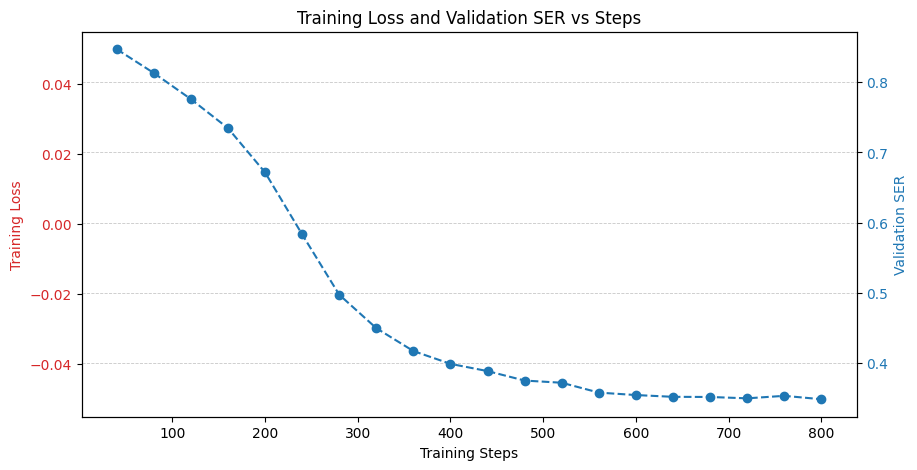

In [39]:
from matplotlib.ticker import FuncFormatter

def plot_training_curves(loss_history, ser_history, step_history):
    """Plots training loss (every step) and validation SER (sparse checkpoints)."""
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Training loss (dense curve)
    color = 'tab:red'
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Training Loss', color=color)
    ax1.plot(range(1, len(loss_history)+1), train_loss_history, color=color, label='Training Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    # Validation SER (sparse points)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Validation SER', color=color)
    ax2.plot(step_history, ser_history, color=color, marker='o', linestyle='--', label='Validation SER')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Training Loss and Validation SER vs Steps')
    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
    plt.show()


# After the training loop finishes:
plot_training_curves(train_loss_history, val_ser_history, step_history)

In [40]:
def evaluate_ser(batch_size, no, speed, num_tx_ant=4, num_rx_ant=8, num_bits_per_symbol=4):
    """
    Evaluate SER for DetNet model and LMMSE equalizer with specified batch size, noise variance, and speed.
    """
    # Create a test dataset with specified batch size, noise variance, and speed
    test_dataset = tf.data.Dataset.from_generator(
        # ---- FIX: Correctly pass arguments to the generator ----
        lambda: cdl_generator(batch_size, num_tx_ant, num_rx_ant, num_bits_per_symbol, no=no, speed=speed),
        output_signature=(
            (tf.TensorSpec(shape=(None, num_rx_ant, num_tx_ant), dtype=tf.complex64),
             tf.TensorSpec(shape=(None, num_rx_ant), dtype=tf.complex64)),
            tf.TensorSpec(shape=(None, num_tx_ant), dtype=tf.complex64)
        )
    ).take(1).prefetch(tf.data.AUTOTUNE)

    # Initialize LMMSE equalizer components
    symbol_demapper = SymbolDemapper("qam", num_bits_per_symbol, hard_out=True)

    # Evaluate on the test dataset
    for inputs, x_true in test_dataset:
        h, y = inputs

        # DetNet evaluation
        x_pred_list = simple_model(inputs, training=False)
        x_pred_final = x_pred_list[-1]
        x_ind_true = symbol_demapper(x_true, 0.1)
        x_hat_hard = symbol_demapper(x_pred_final, 0.1)
        detnet_ser = compute_ser(x_ind_true, x_hat_hard)

        # LMMSE evaluation
        # Define s (noise covariance matrix) before using it
        s = tf.cast(no * tf.eye(num_rx_ant, dtype=tf.complex64), y.dtype)
        x_lmmse, _ = lmmse_equalizer(y, h, s)
        x_lmmse_ind = symbol_demapper(x_lmmse, 0.1)
        lmmse_ser = compute_ser(x_ind_true, x_lmmse_ind)

        # Print results
        print(f"\nEvaluation for Batch Size: {batch_size}, Noise Variance: {no}, Speed: {speed} m/s")
        print(f"DetNet SER: {detnet_ser:.5f}")
        print(f"LMMSE SER: {lmmse_ser:.5f}\n")

In [41]:
batch_size = 200  # Example batch size
noise_variance = 0.25  # Example noise variance
speed = 11.0  # Example speed in m/s
evaluate_ser(batch_size, noise_variance, speed)




Evaluation for Batch Size: 200, Noise Variance: 0.25, Speed: 11.0 m/s
DetNet SER: 0.32750
LMMSE SER: 0.23250



# Saving and loading a pre-trained model

In [42]:
# Define results directory
results_dir = os.path.join(os.getcwd(), "ML_Model")

# Save the model as HDF5 (.h5) (Weughts)
simple_model.save(os.path.join(results_dir, 'detnet_model_tackled_v1.h5'))



In [ ]:
simple_model.summary()

Model: "det_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ det_net_layer (DetNetLayer)     │ ?                      │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ det_net_layer_1 (DetNetLayer)   │ ?                      │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ det_net_layer_2 (DetNetLayer)   │ ?                      │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ det_net_layer_3 (DetNetLayer)   │ ?                      │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ det_net_layer_4 (DetNetLayer)   │ ?                      │           936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,680 (18.28 KB)

 Trainable params: 4,680 (18.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Instantiate a new model
NUM_TX_ANT = 4  # Match your training setup
trained_simple_model = DetNet(num_tx_ant=NUM_TX_ANT, num_layers=5, hidden_dim=16)

# Build the model with dummy input shapes
# trained_simple_model.build([(None, 8, NUM_TX_ANT), (inputs, 8)])
trained_simple_model(inputs)

# Load weights from .h5 file
try:
    trained_simple_model.load_weights(os.path.join(results_dir, 'detnet_model_tackle.h5'))
    print("Weights loaded successfully from .h5 file.")
except Exception as e:
    print(f"Error loading weights: {e}")
    raise

# Verify model parameters
trained_simple_model.summary()

Weights loaded successfully from .h5 file.


Model: "det_net_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ det_net_layer_39 (DetNetLayer)  │ ?                      │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ det_net_layer_40 (DetNetLayer)  │ ?                      │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ det_net_layer_41 (DetNetLayer)  │ ?                      │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ det_net_layer_42 (DetNetLayer)  │ ?                      │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ det_net_layer_43 (DetNetLayer)  │ ?                      │           936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,680 (18.28 KB)

 Trainable params: 4,680 (18.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
inputs[1]

<tf.Tensor: shape=(512, 8), dtype=complex64, numpy=
array([[-1.7083808 -1.2198869j , -0.9821415 -1.9947479j ,
         0.12469751-0.8193322j , ..., -2.5880532 -0.21310425j,
        -2.2538316 -0.06010854j,  0.0563239 -1.1484789j ],
       [-2.9416056 +1.0439938j ,  1.3788569 +0.45189643j,
         2.5109234 +0.4454518j , ..., -4.644894  -1.1337922j ,
        -3.7772162 -0.69408596j, -3.1175284 -0.94086355j],
       [-0.03429741-1.6552539j ,  1.5837513 -0.25572765j,
         0.94392645-0.23726219j, ..., -1.8273133 +1.7714156j ,
        -0.8496566 -0.08690634j,  0.24156743-0.44403806j],
       ...,
       [ 0.66030157+1.3375721j ,  0.7971138 +2.238334j  ,
         1.7098967 +2.209813j  , ..., -0.6683699 -1.508188j  ,
         0.36822107-2.6116052j , -0.64586663-1.502527j  ],
       [-1.0049313 -1.1884813j , -0.64035666+1.1469249j ,
         0.15014932-0.07154939j, ..., -1.2456934 +0.94863224j,
        -2.2056015 +0.11415881j,  0.11340655-0.9287132j ],
       [ 0.11039633+0.6598787j ,  1.

In [ ]:
simple_model = trained_simple_model

In [43]:
# Test predictions with evaluate_ser to confirm weights are loaded
print("Testing model predictions...")
evaluate_ser(batch_size=1024, no=0.25, speed=20.0)

Testing model predictions...

Evaluation for Batch Size: 1024, Noise Variance: 0.25, Speed: 20.0 m/s
DetNet SER: 0.33813
LMMSE SER: 0.24927



# Hyperparameter Optimisation using Optuna

In [ ]:
# !pip install optuna

In [ ]:
import optuna

In [ ]:
# # Fixed Optuna objective with better error handling
# def objective_fixed(trial):
#     """Fixed Optuna objective function with error handling."""
#     # Suggest hyperparameters
#     lr = trial.suggest_float("lr", 1e-3, 1e-2, log=True)
#     hidden_dim = trial.suggest_categorical("hidden_dim", [8, 16, 32])
#     num_layers = trial.suggest_int("num_layers", 4, 7)
#     batch_size = trial.suggest_categorical("batch_size", [256, 512])

#     # Create model and optimizer
#     model = DetNet(num_tx_ant=NUM_TX_ANT, num_layers=num_layers, hidden_dim=hidden_dim)
#     optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

#     # Create dataset with trial's batch size
#     trial_dataset = tf.data.Dataset.from_generator(
#         lambda: cdl_generator(batch_size, NUM_TX_ANT, NUM_RX_ANT, NUM_BITS_PER_SYMBOL, no=0.25),
#         output_signature=(
#             (tf.TensorSpec(shape=(None, NUM_RX_ANT, NUM_TX_ANT), dtype=tf.complex64),
#              tf.TensorSpec(shape=(None, NUM_RX_ANT), dtype=tf.complex64)),
#             tf.TensorSpec(shape=(None, NUM_TX_ANT), dtype=tf.complex64)
#         )
#     ).prefetch(tf.data.AUTOTUNE)

#     val_dataset_trial = tf.data.Dataset.from_generator(
#         lambda: cdl_generator(batch_size, NUM_TX_ANT, NUM_RX_ANT, NUM_BITS_PER_SYMBOL, no=0.25),
#         output_signature=(
#             (tf.TensorSpec(shape=(None, NUM_RX_ANT, NUM_TX_ANT), dtype=tf.complex64),
#              tf.TensorSpec(shape=(None, NUM_RX_ANT), dtype=tf.complex64)),
#             tf.TensorSpec(shape=(None, NUM_TX_ANT), dtype=tf.complex64)
#         )
#     ).prefetch(tf.data.AUTOTUNE)

#     # Training loop
#     train_iterator = iter(trial_dataset)
#     TRAIN_STEPS_FOR_TRIAL = 200
#     VALIDATION_FREQUENCY_TRIAL = 40

#     best_ser = float('inf')

#     for step in range(TRAIN_STEPS_FOR_TRIAL):
#         try:
#             inputs, x_true = next(train_iterator)

#             # Train step
#             with tf.GradientTape() as tape:
#                 h, y = inputs
#                 x_pred_list = model(inputs, training=True)
#                 loss = detnet_loss(x_true, x_pred_list, h, y)

#             grads = tape.gradient(loss, model.trainable_variables)
#             optimizer.apply_gradients(zip(grads, model.trainable_variables))

#             # Validation
#             if (step + 1) % VALIDATION_FREQUENCY_TRIAL == 0:
#                 val_iterator = iter(val_dataset_trial.take(10))
#                 total_ser = 0.0
#                 valid_batches = 0

#                 for _ in range(10):
#                     try:
#                         val_inputs, val_x_true = next(val_iterator)
#                         ser = test_step(model, val_inputs, val_x_true)
#                         total_ser += ser
#                         valid_batches += 1
#                     except:
#                         continue

#                 if valid_batches > 0:
#                     avg_ser = (total_ser / valid_batches).numpy()
#                     best_ser = min(best_ser, avg_ser)

#                     # Report to Optuna
#                     trial.report(avg_ser, step)

#                     # Pruning
#                     if trial.should_prune():
#                         raise optuna.exceptions.TrialPruned()

#         except tf.errors.InvalidArgumentError:
#             # Skip bad batches
#             continue
#         except StopIteration:
#             # Recreate iterator if exhausted
#             train_iterator = iter(trial_dataset)
#             continue

#     return best_ser

In [ ]:
# Run Optuna study with fixed objective
print("\nStarting Optuna hyperparameter optimization...")
study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective_fixed, n_trials=5, timeout=600)  # 10 minute timeout

print("\nBest trial:")
print(f"  Value (SER): {study.best_value}")
print(f"  Params: {study.best_params}")


[I 2025-09-17 08:23:33,472] A new study created in memory with name: no-name-3484ea22-0a35-4f98-8822-2e951d041b39



Starting Optuna hyperparameter optimization...


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['det_net_3/det_net_layer_21/W3/kernel', 'det_net_3/det_net_layer_21/W3/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
[I 2025-09-17 08:27:08,651] Trial 0 finished with value: 0.8185546875 and parameters: {'lr': 0.0029077944109119434, 'hidden_dim': 8, 'num_layers': 4, 'batch_size': 512}. Best is trial 0 with value: 0.8185546875.
/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['det_net_4/det_net_layer_25/W3/kernel', 'det_net_4/det_net_layer_25/W3/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
[I 2025-09-17 08:29:06,359] Trial 1 finished with value: 0.82236328125 and parameters: {'lr': 0.002521385568696779, 'hidden_dim': 


Best trial:
  Value (SER): 0.659521484375
  Params: {'lr': 0.0026085324336445974, 'hidden_dim': 32, 'num_layers': 7, 'batch_size': 512}


In [44]:
def objective_fixed(trial):
    """Fixed Optuna objective function with error handling, tuning only learning rate and optimizer."""
    # Suggest hyperparameters
    lr = trial.suggest_float("lr", 1e-3, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "Adam", "RMSprop", "SGD"])

    # Fixed hyperparameters to match simplified model
    hidden_dim = 16  # Fixed, matching the simplified model
    num_layers = 5   # Fixed, matching the simplified model
    batch_size = 512 # Fixed, matching the training setup

    # Create model
    model = DetNet(num_tx_ant=NUM_TX_ANT, num_layers=num_layers, hidden_dim=hidden_dim)
    dummy_h = tf.zeros([1, NUM_RX_ANT, NUM_TX_ANT], dtype=tf.complex64)
    dummy_y = tf.zeros([1, NUM_RX_ANT], dtype=tf.complex64)
    model((dummy_h, dummy_y), training=False)  # Build model

    # Select optimizer based on suggested name
    if optimizer_name == "Adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "AdamW":
        optimizer = tf.keras.optimizers.experimental.AdamW(learning_rate=lr, weight_decay=1e-4)
    elif optimizer_name == "RMSprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr, rho=0.9, momentum=0.0)
    elif optimizer_name == "SGD":
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)

    # Create dataset with fixed batch size
    trial_dataset = tf.data.Dataset.from_generator(
        lambda: cdl_generator(batch_size, NUM_TX_ANT, NUM_RX_ANT, NUM_BITS_PER_SYMBOL, no=0.25),
        output_signature=(
            (tf.TensorSpec(shape=(None, NUM_RX_ANT, NUM_TX_ANT), dtype=tf.complex64),
             tf.TensorSpec(shape=(None, NUM_RX_ANT), dtype=tf.complex64)),
            tf.TensorSpec(shape=(None, NUM_TX_ANT), dtype=tf.complex64)
        )
    ).prefetch(tf.data.AUTOTUNE)

    val_dataset_trial = tf.data.Dataset.from_generator(
        lambda: cdl_generator(batch_size, NUM_TX_ANT, NUM_RX_ANT, NUM_BITS_PER_SYMBOL, no=0.25),
        output_signature=(
            (tf.TensorSpec(shape=(None, NUM_RX_ANT, NUM_TX_ANT), dtype=tf.complex64),
             tf.TensorSpec(shape=(None, NUM_RX_ANT), dtype=tf.complex64)),
            tf.TensorSpec(shape=(None, NUM_TX_ANT), dtype=tf.complex64)
        )
    ).prefetch(tf.data.AUTOTUNE)

    # Training loop
    train_iterator = iter(trial_dataset)
    TRAIN_STEPS_FOR_TRIAL = 200
    VALIDATION_FREQUENCY_TRIAL = 40

    best_ser = float('inf')

    for step in range(TRAIN_STEPS_FOR_TRIAL):
        try:
            inputs, x_true = next(train_iterator)

            # Train step
            with tf.GradientTape() as tape:
                h, y = inputs
                x_pred_list = model(inputs, training=True)
                loss = detnet_loss(x_true, x_pred_list, h, y)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            # Validation
            if (step + 1) % VALIDATION_FREQUENCY_TRIAL == 0:
                val_iterator = iter(val_dataset_trial.take(10))
                total_ser = 0.0
                valid_batches = 0

                for _ in range(10):
                    try:
                        val_inputs, val_x_true = next(val_iterator)
                        ser = test_step(model, val_inputs, val_x_true, 0.25)  # Use FIXED_NO=0.25 for consistency
                        total_ser += ser
                        valid_batches += 1
                    except:
                        continue

                if valid_batches > 0:
                    avg_ser = (total_ser / valid_batches).numpy()
                    best_ser = min(best_ser, avg_ser)

                    # Report to Optuna
                    trial.report(avg_ser, step)

                    # Handle pruning
                    if trial.should_prune():
                        raise optuna.exceptions.TrialPruned()

        except tf.errors.InvalidArgumentError:
            # Skip bad batches
            continue
        except StopIteration:
            # Recreate iterator if exhausted
            train_iterator = iter(trial_dataset)
            continue

    return best_ser

# --- Run the Optuna Study ---
# Use a pruner to stop unpromising trials early
pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction="minimize", pruner=pruner)
study.optimize(objective_fixed, n_trials=10)  # Run 10 trials

print("Best trial:")
trial = study.best_trial
print(f"  Value (SER): {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-09-17 08:49:48,827] A new study created in memory with name: no-name-af686a2b-3959-4c24-a8ba-e1f64fcaa9a6
/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['det_net_10/det_net_layer_58/W3/kernel', 'det_net_10/det_net_layer_58/W3/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
[I 2025-09-17 08:53:21,211] Trial 0 finished with value: inf and parameters: {'lr': 0.005307298964639046, 'optimizer': 'SGD'}. Best is trial 0 with value: inf.
/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['det_net_11/det_net_layer_63/W3/kernel', 'det_net_11/det_net_layer_63/W3/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
[I 2025-09-17 08:56:51,717] Trial 1 finished with value: inf and

KeyboardInterrupt: 